
# Notebook 02 - Train PPO và đánh giá mô hình

Notebook này sẽ dùng file `workload_real.csv` từ notebook 1 để:

1. đọc workload
2. tạo môi trường RL
3. train PPO
4. so sánh với baseline
5. lưu bảng kết quả và biểu đồ

## Nhắc lại mục tiêu đề tài
Ta muốn agent học cách:
- bật thêm host khi tải cao
- cho host ngủ khi tải thấp
- tăng/giảm DVFS
- để **giảm năng lượng** nhưng vẫn **giữ SLA ổn**


In [1]:

# Nếu thiếu thư viện thì bỏ comment và chạy 1 lần:
!pip install gymnasium stable-baselines3 tensorboard tqdm rich pandas matplotlib


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:

import os
import sys
from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.energy_env import CloudEnergyEnv, EnvConfig, load_workload_csv
from src.baselines import (
    FixedPolicy,
    RoundRobinPolicy,
    ThresholdPolicy,
    BestFitLikePolicy,
    run_policy,
)
from src.evaluation import save_trace_artifacts

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = C:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\azure_drl_beginner_project\azure_drl_beginner_project



## Bước 1 - Khai báo đường dẫn file workload

Nếu notebook 1 chạy xong đúng, file này đã nằm sẵn trong `data/`.


In [3]:

WORKLOAD_PATH = PROJECT_ROOT / "data" / "workload_real.csv"
WORKLOAD_PATH


WindowsPath('C:/Users/PHUONG NGHI/Desktop/NT549.Q21-DRL-ERM-Cloud/azure_drl_beginner_project/azure_drl_beginner_project/data/workload_real.csv')

In [4]:

if not WORKLOAD_PATH.exists():
    raise FileNotFoundError(
        f"Không thấy file {WORKLOAD_PATH}. Hãy chạy notebook 01 trước."
    )



## Bước 2 - Đọc workload và xem nhanh dữ liệu


In [5]:

workload_df = pd.read_csv(WORKLOAD_PATH)
display(workload_df.head())
display(workload_df.describe())


,timestep,demand,raw_core_demand,active_vm_count
0,0,0.989552,113390.769344,875495
1,1,0.988060,113219.745314,875378
2,2,0.985733,112953.144655,874422
3,3,0.984784,112844.379743,870308
4,4,0.987856,113196.421713,871064


,timestep,demand,raw_core_demand,active_vm_count
count,720.000000,720.000000,720.000000,720.000000
mean,359.500000,0.885871,101510.132917,793495.206944
std,207.990384,0.064989,7446.923959,62652.022796
min,0.000000,0.789629,90482.014597,695993.000000
25%,179.750000,0.826326,94687.048647,729997.500000
50%,359.500000,0.880510,100895.873880,793957.500000
75%,539.250000,0.925099,106005.191502,852517.000000
max,719.000000,1.022893,117211.225609,901284.000000



## Bước 3 - Vẽ lại demand để chắc chắn đầu vào ổn


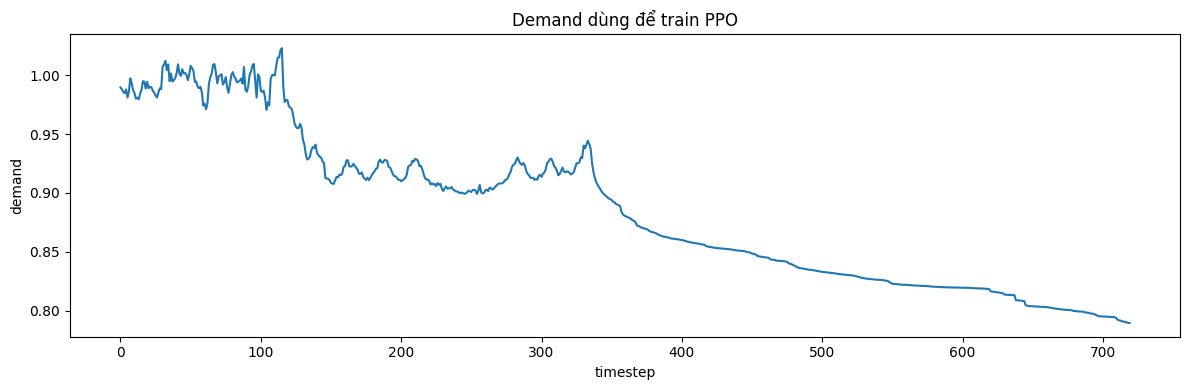

In [6]:

plt.figure(figsize=(12, 4))
plt.plot(workload_df["timestep"], workload_df["demand"])
plt.title("Demand dùng để train PPO")
plt.xlabel("timestep")
plt.ylabel("demand")
plt.tight_layout()
plt.show()



## Bước 4 - Tạo environment config

### Giải thích ngắn:
- `max_hosts`: cụm có tối đa bao nhiêu host
- `dvfs_levels`: các mức DVFS cho host
- `p_idle`, `p_peak`, `p_sleep`: power model
- `reward_w_energy`, `reward_w_sla`, `reward_w_switch`, `reward_w_util`: trọng số reward

> Lưu ý: nếu PPO chưa tiết kiệm điện tốt, thường bạn sẽ chỉnh chính các trọng số reward này.


In [7]:

workload = load_workload_csv(str(WORKLOAD_PATH))
episode_length = len(workload) - 1
config = EnvConfig(
    max_hosts=8,
    min_active_hosts=1,
    episode_length=episode_length,
    dvfs_levels=(0.6, 0.8, 1.0, 1.2),
    host_nominal_capacity=1.0 / 8.0,
    p_idle=80.0,
    p_peak=200.0,
    p_sleep=10.0,
    host_switch_cost=8.0,

    reward_w_energy=1.0,
    reward_w_sla=4.0,
    reward_w_switch=0.30,
    reward_w_util=0.30,
    reward_w_migration=0.20,
    reward_w_temp=0.20,
    reward_w_lifetime=0.10,
    seed=42,
)

config


EnvConfig(max_hosts=8, min_active_hosts=1, min_sleep_hosts=0, episode_length=719, dvfs_levels=(0.6, 0.8, 1.0, 1.2), host_nominal_capacity=0.125, p_idle=80.0, p_peak=200.0, p_sleep=10.0, p_off=1.0, host_switch_cost=8.0, migration_cost=1.5, reward_w_energy=1.0, reward_w_sla=4.0, reward_w_switch=0.3, reward_w_migration=0.2, reward_w_util=0.3, reward_w_temp=0.2, reward_w_lifetime=0.1, base_pue=1.18, cooling_alpha=0.08, cooling_beta=0.18, cooling_fixed_power=25.0, ambient_temp_c=24.0, temp_idle_c=33.0, temp_rise_per_util=30.0, temp_rise_per_dvfs=10.0, temp_smoothing=0.3, reference_temp_c=35.0, max_safe_temp_c=80.0, aging_temp_threshold_c=45.0, aging_per_step_base=1.0, aging_temp_factor=0.03, vm_unit_demand=0.05, seed=42)


## Bước 5 - Test environment trước khi train
Nếu cell này chạy ổn thì environment của bạn hợp lệ.


In [8]:

env = CloudEnergyEnv(workload=workload, config=config)
check_env(env, warn=True)
print("Environment hợp lệ.")


Environment hợp lệ.



## Bước 6 - Chạy thử vài bước để hiểu agent đang nhìn thấy gì

Ở đây:
- `obs` là state
- `action` là quyết định
- `reward` là thưởng/phạt
- `info` là thông tin chi tiết ở từng bước


In [9]:

obs, _ = env.reset(seed=42)
print("obs ban đầu =", obs)

for step in range(3):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {step + 1}")
    print("action =", action)
    print("reward =", reward)
    print("info =", info)


obs ban đầu = [0.989552   0.9880595  0.5        0.8333333  0.42474908 0.49472085
 0.247388   0.25709313 0.5        0.         0.4310467  0.37933487
 0.001      0.        ]

Step 1
action = 5
reward = -14.52416040569793
info = {'demand': 0.9895520210266113, 'power_it': 755.9910278320312, 'power': 1014.3904172132438, 'power_total': 1014.3904172132438, 'pue': 1.341802190592432, 'sla_violation': 0.4947208541080289, 'active_hosts': 4, 'sleep_hosts': 3, 'off_hosts': 1, 'dvfs': 1.0, 'mean_util': 0.9687312841415405, 'switches': 1, 'wake_from_off': 0, 'migrations': 0, 'avg_temp': 34.677040100097656, 'max_temp': 45.93000030517578, 'thermal_penalty': 0.0, 'lifetime_penalty': 0.027900009155273464, 'mean_host_age': 1.8972375392913818, 'sla': 0.4947208541080289, 'migration_plan': [], 'cooling_power': 258.3993893812126, 'host_loads': [0.6926863789558411, 0.0989551991224289, 0.0989551991224289, 0.0989551991224289, 0.0, 0.0, 0.0, 0.0], 'host_temps': [45.93000030517578, 42.74211502075195, 42.74211502075


## Bước 7 - Tạo hàm build environment cho PPO


In [10]:

def make_env():
    return Monitor(CloudEnergyEnv(workload=workload, config=config))



## Bước 8 - Khai báo tham số train
- `TOTAL_TIMESTEPS` càng lớn thì agent có nhiều cơ hội học hơn
- khi mới chạy thử, bạn có thể để 60,000
- muốn kết quả tốt hơn thì có thể tăng lên 200,000 hoặc hơn


In [11]:

MODEL_PATH = PROJECT_ROOT / "outputs" / "ppo_cloud_energy_from_real_workload"
RESULT_CSV = PROJECT_ROOT / "outputs" / "evaluation_results_real_workload.csv"

TOTAL_TIMESTEPS = 300_000 
# fix từ 60_000 xuống 30_000 để rút ngắn thời gian train, 
# vì dữ liệu thật có thể không cần train lâu như dữ liệu giả
MODEL_PATH, RESULT_CSV, TOTAL_TIMESTEPS


(WindowsPath('C:/Users/PHUONG NGHI/Desktop/NT549.Q21-DRL-ERM-Cloud/azure_drl_beginner_project/azure_drl_beginner_project/outputs/ppo_cloud_energy_from_real_workload'),
 WindowsPath('C:/Users/PHUONG NGHI/Desktop/NT549.Q21-DRL-ERM-Cloud/azure_drl_beginner_project/azure_drl_beginner_project/outputs/evaluation_results_real_workload.csv'),
 300000)


## Bước 9 - Train PPO
Nếu máy bạn chưa có tensorboard hoặc progress bar đẹp, code vẫn train bình thường.


In [ ]:

vec_env = DummyVecEnv([make_env])

has_tensorboard = importlib.util.find_spec("tensorboard") is not None
has_progress_bar = (
    importlib.util.find_spec("tqdm") is not None
    and importlib.util.find_spec("rich") is not None
)

model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=1,
    tensorboard_log=str(PROJECT_ROOT / "outputs" / "tb_logs") if has_tensorboard else None,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=has_progress_bar)
model.save(str(MODEL_PATH))

print("Đã lưu model tại:", str(MODEL_PATH) + ".zip")


Using cpu device
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 719       |
|    ep_rew_mean     | -7.04e+03 |
| time/              |           |
|    fps             | 979       |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 1024      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 719         |
|    ep_rew_mean          | -7.05e+03   |
| time/                   |             |
|    fps                  | 986         |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.002609131 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.94       |
|    explained_variance   | 0.00108     |
|  


## Bước 10 - Chạy baseline và PPO để đánh giá

Ta sẽ so sánh:
- Fixed-Keep
- Threshold
- BestFitLike
- PPO

> Lưu ý: `BestFitLike` ở đây là heuristic xấp xỉ Best Fit ở mức **cluster-level**,  
không phải placement VM chi tiết từng server.


In [ ]:

def evaluate_once(policy_name: str, policy, workload, config):
    env_local = CloudEnergyEnv(workload=workload, config=config)
    metrics = run_policy(env_local, policy)
    return {
        "policy": policy_name,
        "total_reward": metrics.total_reward,
        "total_energy": metrics.total_energy,
        "total_it_energy": metrics.total_it_energy,
        "avg_power": metrics.avg_power,
        "avg_pue": metrics.avg_pue,
        "sla_rate": metrics.sla_rate,
        "avg_active_hosts": metrics.avg_active_hosts,
        "avg_sleep_hosts": metrics.avg_sleep_hosts,
        "avg_off_hosts": metrics.avg_off_hosts,
        "avg_temp": metrics.avg_temp,
        "total_switches": metrics.total_switches,
        "total_migrations": metrics.total_migrations,
    }

rows = []
rows.append(evaluate_once("Fixed-Keep", FixedPolicy(0), workload, config))
rows.append(evaluate_once("RoundRobin", RoundRobinPolicy(), workload, config))
rows.append(evaluate_once("Threshold", ThresholdPolicy(), workload, config))
rows.append(evaluate_once("BestFitLike", BestFitLikePolicy(), workload, config))
rr_env = CloudEnergyEnv(workload=workload, config=config)
rr_metrics = run_policy(rr_env, RoundRobinPolicy())
save_trace_artifacts(rr_env.trace, PROJECT_ROOT / "outputs", prefix="round_robin")
ppo_env = CloudEnergyEnv(workload=workload, config=config)
loaded_model = PPO.load(str(MODEL_PATH) + ".zip")
ppo_metrics = run_policy(ppo_env, loaded_model)
save_trace_artifacts(ppo_env.trace, PROJECT_ROOT / "outputs", prefix="ppo")
rows.append({
    "policy": "PPO",
    "total_reward": ppo_metrics.total_reward,
    "total_energy": ppo_metrics.total_energy,
    "total_it_energy": ppo_metrics.total_it_energy,
    "avg_power": ppo_metrics.avg_power,
    "avg_pue": ppo_metrics.avg_pue,
    "sla_rate": ppo_metrics.sla_rate,
    "avg_active_hosts": ppo_metrics.avg_active_hosts,
    "avg_sleep_hosts": ppo_metrics.avg_sleep_hosts,
    "avg_off_hosts": ppo_metrics.avg_off_hosts,
    "avg_temp": ppo_metrics.avg_temp,
    "total_switches": ppo_metrics.total_switches,
    "total_migrations": ppo_metrics.total_migrations,
})

results_df = pd.DataFrame(rows)
results_df


,policy,total_reward,total_energy,total_it_energy,avg_power,avg_pue,sla_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_temp,total_switches,total_migrations
0,Fixed-Keep,-8618.049135,7.921496e+05,5.460236e+05,1101.737962,1.450752,0.432694,4.000000,4.000000,0.0,44.933880,0,0.0
1,RoundRobin,-611.346414,1.438040e+06,1.011598e+06,2000.055025,1.421399,0.002979,7.977747,0.022253,0.0,60.892327,4,0.0
2,Threshold,-706.882051,1.681502e+06,1.191622e+06,2338.667873,1.410412,0.001004,7.991655,0.008345,0.0,61.011528,4,0.0
3,BestFitLike,-706.882051,1.681502e+06,1.191622e+06,2338.667873,1.410412,0.001004,7.991655,0.008345,0.0,61.011528,4,0.0
4,PPO,-747.349466,1.527906e+06,NaN,2125.042915,NaN,0.013519,7.991655,NaN,NaN,NaN,4,NaN



## Bước 11 - Lưu bảng kết quả ra CSV


In [ ]:

RESULT_CSV.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(RESULT_CSV, index=False)
print("Đã lưu:", RESULT_CSV)


Đã lưu: C:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\azure_drl_beginner_project\azure_drl_beginner_project\outputs\evaluation_results_real_workload.csv



## Bước 12 - Vẽ biểu đồ so sánh năng lượng
Cột càng thấp thì càng tiết kiệm điện hơn.


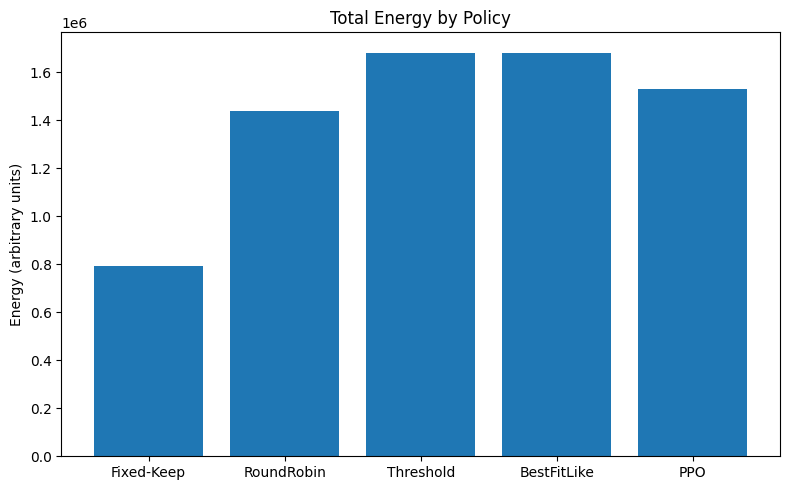

In [ ]:

plt.figure(figsize=(8, 5))
plt.bar(results_df["policy"], results_df["total_energy"])
plt.title("Total Energy by Policy")
plt.ylabel("Energy (arbitrary units)")
plt.tight_layout()
plt.show()



## Bước 13 - Vẽ biểu đồ so sánh SLA
Cột càng thấp thì càng ít vi phạm SLA.


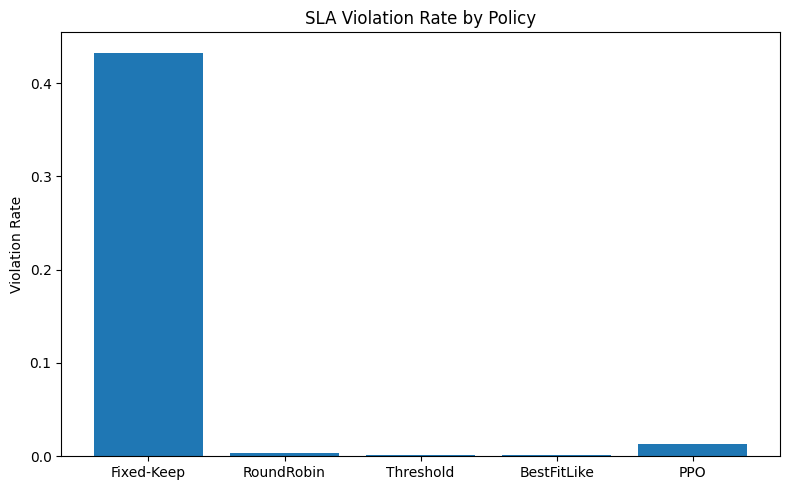

In [ ]:

plt.figure(figsize=(8, 5))
plt.bar(results_df["policy"], results_df["sla_rate"])
plt.title("SLA Violation Rate by Policy")
plt.ylabel("Violation Rate")
plt.tight_layout()
plt.show()



## Bước 14 - Kết luận nhanh từ kết quả

Cách đọc:
- `total_energy` thấp hơn -> tiết kiệm điện hơn
- `sla_rate` thấp hơn -> ít quá tải hơn
- `avg_active_hosts` thấp hơn -> cụm dùng ít host hơn
- `total_switches` thấp hơn -> ít bật/tắt hơn

### Cẩn thận
Một policy có thể:
- tiết kiệm điện hơn
- nhưng lại vi phạm SLA nhiều hơn

Cho nên bạn không được nhìn mỗi `energy`, mà phải nhìn **trade-off giữa energy và SLA**.



## Bước 15 - Bạn nên làm gì tiếp theo sau khi chạy notebook này?

Nếu kết quả PPO chưa đẹp, bạn làm theo thứ tự này:

1. Tăng `TOTAL_TIMESTEPS`
2. Chỉnh reward:
   - tăng `reward_w_energy` nếu muốn tiết kiệm điện mạnh hơn
   - tăng `reward_w_sla` nếu muốn giảm vi phạm SLA mạnh hơn
3. Train nhiều lần với seed khác nhau
4. Lấy trung bình kết quả để đưa vào báo cáo

## Gợi ý viết báo cáo
Bạn có thể mô tả pipeline của nhóm như sau:

- Dữ liệu workload được trích xuất từ AzurePackingTraceV1 ở định dạng SQLite
- Từ bảng `vm` và `vmType`, nhóm xây dựng chuỗi nhu cầu tài nguyên theo thời gian
- Chuỗi này được chuẩn hóa thành `demand` để đưa vào môi trường DRL
- Môi trường mô phỏng trạng thái host, mức DVFS, power và SLA
- Tác nhân PPO học chính sách điều khiển tài nguyên nhằm cân bằng giữa tiết kiệm điện và đảm bảo SLA
